In [40]:
import torch

def quant_tensor_sym(tensor, bits=4, group_size=128, q_scale_thresh=1e-5):
    """Quantize and de-quantize tensor asymmetrically. full range, credict goes to llamacpp community

    Args:
        tensor: Tensor containing the tensor to be quantized
        bits: Number of bits for quantization (e.g., 2, 3, 4, 8)
        group_size: Number of elements to share scale for quantization
        v: Rounding value perturbation
        min_scale: Minimum scale coefficient for tensor
        max_scale: Maximum scale coefficient for tensor
        tensor_min (Tensor, optional): Minimum tensor value for quantization. Defaults to None.
        tensor_max (Tensor, optional): Maximum tensor value for quantization. Defaults to None.
        scale_dtype: dtype of the quantized scale,as most kernels only support FP16 or FP32, while this value is import
        q_scale_thresh: clip the quantized scale's magnitude to this value to improve the numerical stability

    Returns:
        Quantized and de-quantized tensor, scale, zero-point
    """
    assert len(tensor.shape) == 2
    assert tensor.shape[1] % group_size == 0
    orig_shape = tensor.shape
    tensor = tensor.reshape(-1, group_size)
    maxq = 2 ** (bits - 1)

    wmin_abs = -torch.clamp(tensor.min(-1)[0], max=0)
    wmax_abs = torch.clamp(tensor.max(-1)[0], min=0)

    max_v = (2 * (wmax_abs < wmin_abs).int() - 1) * torch.max(wmax_abs, wmin_abs)
    scale = (max_v / maxq)
    scale = torch.where(scale < 0, torch.clamp(scale, max=-q_scale_thresh), torch.clamp(scale, min=q_scale_thresh))
    zp = torch.full_like(scale, maxq)  # pylint: disable=E1130
    scale = scale.unsqueeze(dim=-1)
    zp = zp.unsqueeze(dim=-1)
    int_w = torch.round(tensor / scale)
    q = torch.clamp(int_w + zp, 0, 2 ** bits - 1)
    qdq_result = (scale * (q - zp))
    return qdq_result.reshape(orig_shape), scale, zp

def quant_tensor_sym_brevitas(tensor, bits=4, group_size=128, q_scale_thresh=1e-5):
    """Quantize and de-quantize tensor asymmetrically. full range, credict goes to llamacpp community

    Args:
        tensor: Tensor containing the tensor to be quantized
        bits: Number of bits for quantization (e.g., 2, 3, 4, 8)
        group_size: Number of elements to share scale for quantization
        v: Rounding value perturbation
        min_scale: Minimum scale coefficient for tensor
        max_scale: Maximum scale coefficient for tensor
        tensor_min (Tensor, optional): Minimum tensor value for quantization. Defaults to None.
        tensor_max (Tensor, optional): Maximum tensor value for quantization. Defaults to None.
        scale_dtype: dtype of the quantized scale,as most kernels only support FP16 or FP32, while this value is import
        q_scale_thresh: clip the quantized scale's magnitude to this value to improve the numerical stability

    Returns:
        Quantized and de-quantized tensor, scale, zero-point
    """
    orig_shape = tensor.shape
    tensor = tensor.reshape(-1, group_size)
    maxq = 2 ** (bits - 1)

    max_v = torch.abs(tensor).max(-1)[0]
    scale = (max_v / maxq)
    scale = torch.where(scale < 0, torch.clamp(scale, max=-q_scale_thresh), torch.clamp(scale, min=q_scale_thresh))
    zp = torch.full_like(scale, 0.)  # pylint: disable=E1130
    scale = scale.unsqueeze(dim=-1)
    zp = zp.unsqueeze(dim=-1)
    int_w = torch.round(tensor / scale)
    q = torch.clamp(int_w + zp, -maxq, maxq-1)
    qdq_result = (scale * (q - zp))
    return qdq_result.reshape(orig_shape), scale, zp

torch.manual_seed(0)
tensor = torch.randn((768, 768))
qdq_result, _, _ = quant_tensor_sym(tensor, bits=2)
qdq_result_brevitas, _, _ = quant_tensor_sym_brevitas(tensor, bits=2)
print(torch.max(torch.abs(qdq_result - qdq_result_brevitas)))
print(qdq_result)

tensor(2.3291)
tensor([[-1.7053, -1.7053, -0.0000,  ...,  1.2483, -0.0000, -0.0000],
        [-0.0000, -0.0000,  1.5573,  ..., -0.0000, -0.0000,  1.8626],
        [-1.3529,  1.3529, -1.3529,  ..., -0.0000,  1.5487, -1.5487],
        ...,
        [-1.5595,  1.5595,  1.5595,  ..., -0.0000, -0.0000, -1.6207],
        [ 1.5041, -0.0000, -0.0000,  ...,  0.0000,  0.0000,  1.3178],
        [ 1.1613, -0.0000,  1.1613,  ...,  1.8376,  0.0000,  0.0000]])


In [2]:
from transformers import AutoModelForCausalLM
kwargs = {"torch_dtype": torch.float32}
model = AutoModelForCausalLM.from_pretrained("facebook/opt-125m", **kwargs)

block = model.model.decoder.layers[0]
weights = [(name, module.weight.data) for name, module in block.named_modules() if isinstance(module, torch.nn.Linear)]

/home/pmonteag/.local/miniforge3/envs/brevitas_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/pmonteag/.local/miniforge3/envs/brevitas_env/lib/python3.12/site-packages/onnxscript/converter.py:823: FutureWarning: 'onnxscript.values.Op.param_schemas' is deprecated in version 0.1 and will be removed in the future. Please use '.op_signature' instead.
  param_schemas = callee.param_schemas()
/home/pmonteag/.local/miniforge3/envs/brevitas_env/lib/python3.12/site-packages/onnxscript/converter.py:823: FutureWarning: 'onnxscript.values.OnnxFunction.param_schemas' is deprecated in version 0.1 and will be removed in the future. Please use '.op_signature' instead.
  param_schemas = callee.param_schemas()


In [7]:
print(weights[0])

('self_attn.k_proj', tensor([[ 7.8796e-02,  9.4938e-04,  6.5308e-03,  ..., -4.6875e-02,
          3.9642e-02,  1.1843e-04],
        [ 2.0361e-01,  1.6589e-01, -3.3989e-03,  ..., -4.5959e-02,
         -4.7058e-02, -4.8035e-02],
        [ 3.6865e-02,  1.2341e-01,  3.0731e-02,  ..., -8.3252e-02,
          2.4887e-02,  1.9882e-02],
        ...,
        [ 8.6426e-02,  2.7046e-03, -4.4518e-03,  ..., -1.8738e-02,
          2.8839e-02,  4.8431e-02],
        [ 9.1064e-02,  6.3049e-02,  7.2327e-02,  ..., -1.2463e-01,
          1.1230e-01,  2.4750e-02],
        [-9.3460e-04, -2.8748e-02,  2.5269e-02,  ...,  3.5706e-02,
         -1.1932e-01,  3.1067e-02]]))


In [34]:
# Variables
bits = 2
group_size = 128
q_scale_thresh = 1e-5

tensor = weights[0][1]
orig_shape = tensor.shape
tensor = tensor.reshape(-1, group_size)
maxq = 2 ** (bits - 1)

wmin_abs = -torch.clamp(tensor.min(-1)[0], max=0)
wmax_abs = torch.clamp(tensor.max(-1)[0], min=0)

max_v = (2 * (wmax_abs < wmin_abs).int() - 1) * torch.max(wmax_abs, wmin_abs)
scale = (max_v / maxq)
scale = torch.where(scale < 0, torch.clamp(scale, max=-q_scale_thresh), torch.clamp(scale, min=q_scale_thresh))
zp = torch.full_like(scale, maxq)  # pylint: disable=E1130
scale = scale.unsqueeze(dim=-1)
zp = zp.unsqueeze(dim=-1)
int_w = torch.round(tensor / scale)
q = torch.clamp(int_w + zp, 0, 2 ** bits - 1)
qdq_result = (scale * (q - zp))

In [38]:
print(torch.max(tensor))
print(tensor.shape)
print((tensor==torch.max(tensor)).nonzero(), torch.max(tensor))
print((tensor==torch.min(tensor)).nonzero(), torch.min(tensor))

breakpoint()
values, indices = torch.max(torch.abs(tensor), dim=1)
scale = tensor

print(tensor[3161, 66])
print(int_w[3161, 66])
print(wmin_abs[3161], wmax_abs[3161])
print( (2 * (wmax_abs < wmin_abs).int() - 1)[3161]) 
print(max_v[3161])
print(q[3161, 66])
print(qdq_result[3161, 66])
# Also study group 33

tensor(0.7681)
torch.Size([4608, 128])
tensor([[3161,   66]]) tensor(0.7681)
tensor([[3179,   66]]) tensor(-0.7021)


tensor(0.7681)
tensor(2.)
tensor(0.2546) tensor(0.7681)
tensor(-1, dtype=torch.int32)
tensor(0.7681)
tensor(3.)
tensor(0.3840)


In [43]:
# Variables
bits = 2
group_size = 128
q_scale_thresh = 1e-5

tensor = weights[0][1]
orig_shape = tensor.shape
tensor = tensor.reshape(-1, group_size)
maxq = 2 ** (bits - 1)

max_v = torch.abs(tensor).max(-1)[0]
scale = (max_v / maxq)
scale = torch.where(scale < 0, torch.clamp(scale, max=-q_scale_thresh), torch.clamp(scale, min=q_scale_thresh))
zp = torch.full_like(scale, maxq)  # pylint: disable=E1130
scale = scale.unsqueeze(dim=-1)
zp = zp.unsqueeze(dim=-1)
int_w = torch.round(tensor / scale)
q = torch.clamp(int_w + zp, 0, 2 ** bits - 1)
qdq_result = (scale * (q - zp))

In [44]:
print(torch.max(tensor))
print(tensor.shape)
print((tensor==torch.max(tensor)).nonzero(), torch.max(tensor))
print((tensor==torch.min(tensor)).nonzero(), torch.min(tensor))
print(scale.shape)
print(tensor[3161, 66])
print(int_w[3161, 66])
print(wmin_abs[3161], wmax_abs[3161])
print( (2 * (wmax_abs < wmin_abs).int() - 1)[3161]) 
print(max_v[3161])
print(q[3161, 66])
print(qdq_result[3161, 66])
# Also study group 33

tensor(0.7681)
torch.Size([4608, 128])
tensor([[3161,   66]]) tensor(0.7681)
tensor([[3179,   66]]) tensor(-0.7021)
torch.Size([4608, 1])
tensor(0.7681)
tensor(2.)
tensor(0.2546) tensor(0.7681)
tensor(-1, dtype=torch.int32)
tensor(0.7681)
tensor(3.)
tensor(0.3840)


In [55]:
print(tensor.shape)
values, indices = torch.max(torch.abs(tensor), dim=1)
rows = torch.arange(tensor.size(0))
scales = (-torch.sign(tensor[rows, indices])*values).unsqueeze(1)
print(scales.shape)

torch.Size([768, 768])
torch.Size([768, 1])


In [71]:
tensor = weights[0][1]
orig_shape = tensor.shape

tensor = tensor.reshape(-1, tensor.shape[1] // 128, 128)
values, indices = torch.max(torch.abs(tensor), keepdim=True, dim=2)

print(indices.shape)
print(torch.gather(tensor, 2, indices)[0,0,0])
print(values.shape)

torch.Size([768, 6, 1])
tensor(0.3286)
torch.Size([768, 6, 1])


tensor(18694.9688) tensor(19000.2266)


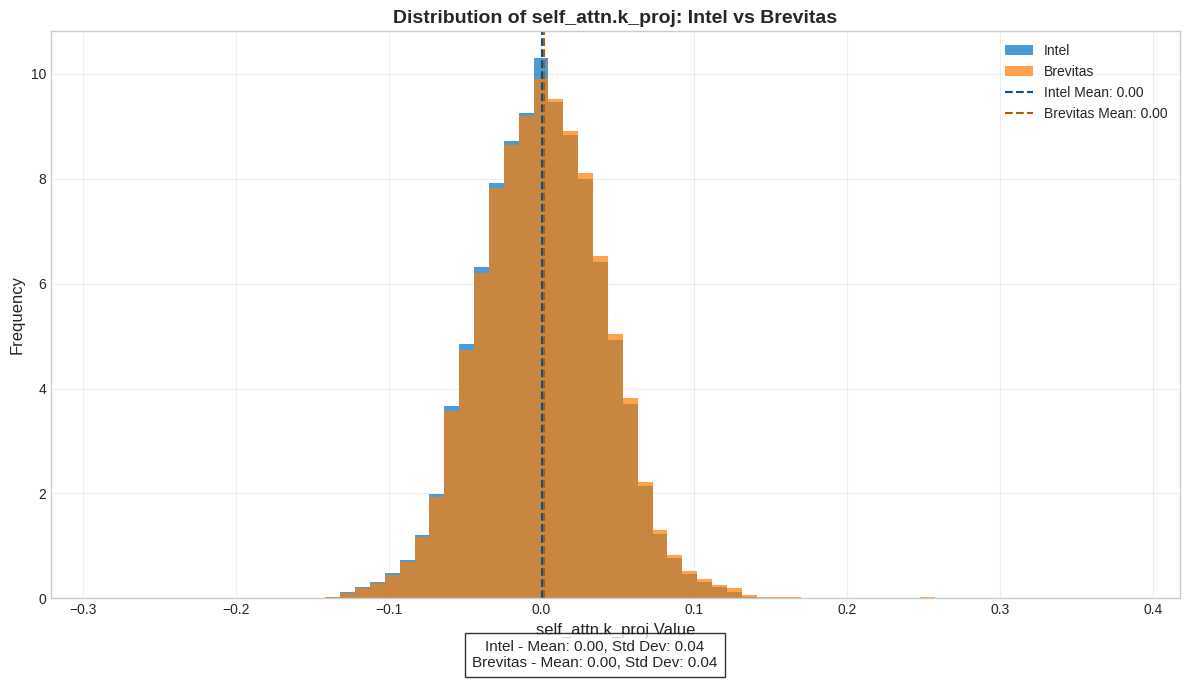

Created plot for self_attn.k_proj and saved to error_distribution_plots/01_self_attn.k_proj.png
tensor(2828.0234) tensor(2872.3909)


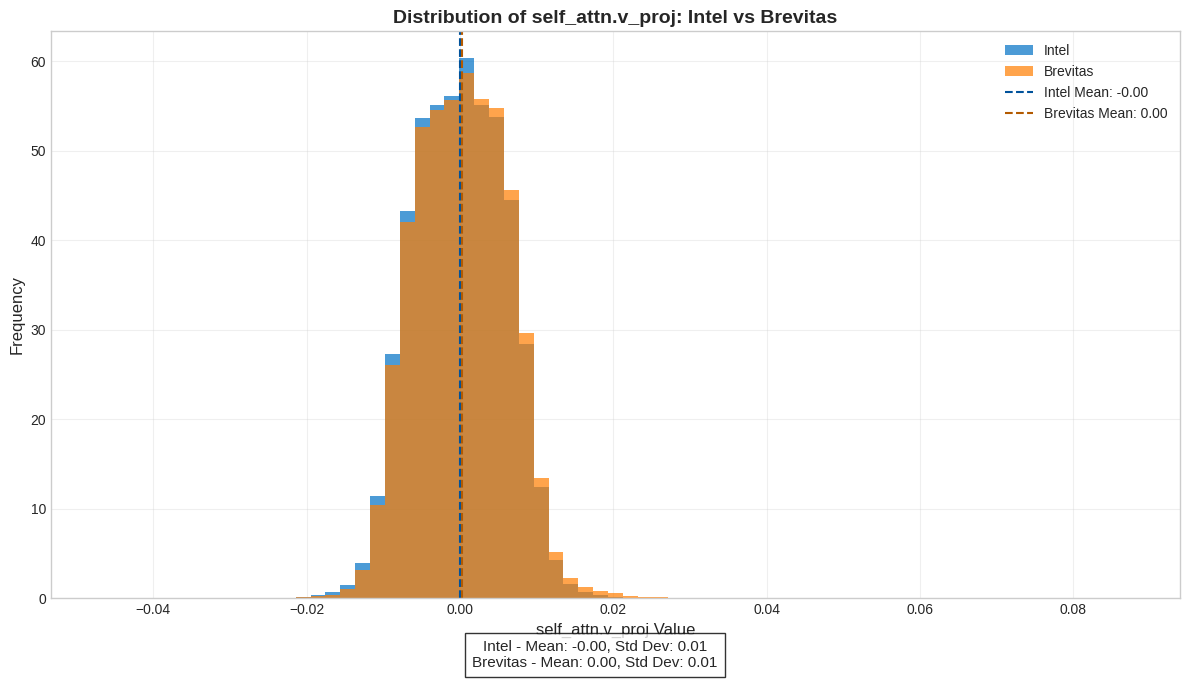

Created plot for self_attn.v_proj and saved to error_distribution_plots/02_self_attn.v_proj.png
tensor(17616.6133) tensor(17898.4297)


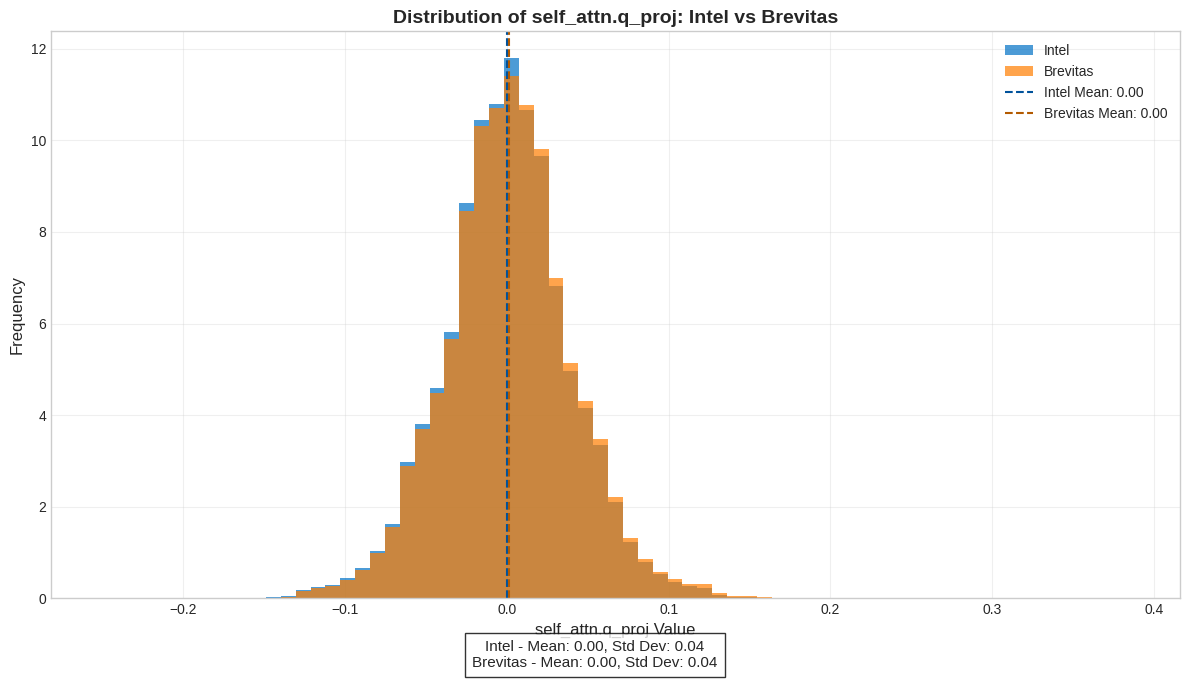

Created plot for self_attn.q_proj and saved to error_distribution_plots/03_self_attn.q_proj.png
tensor(2581.2793) tensor(2623.3225)


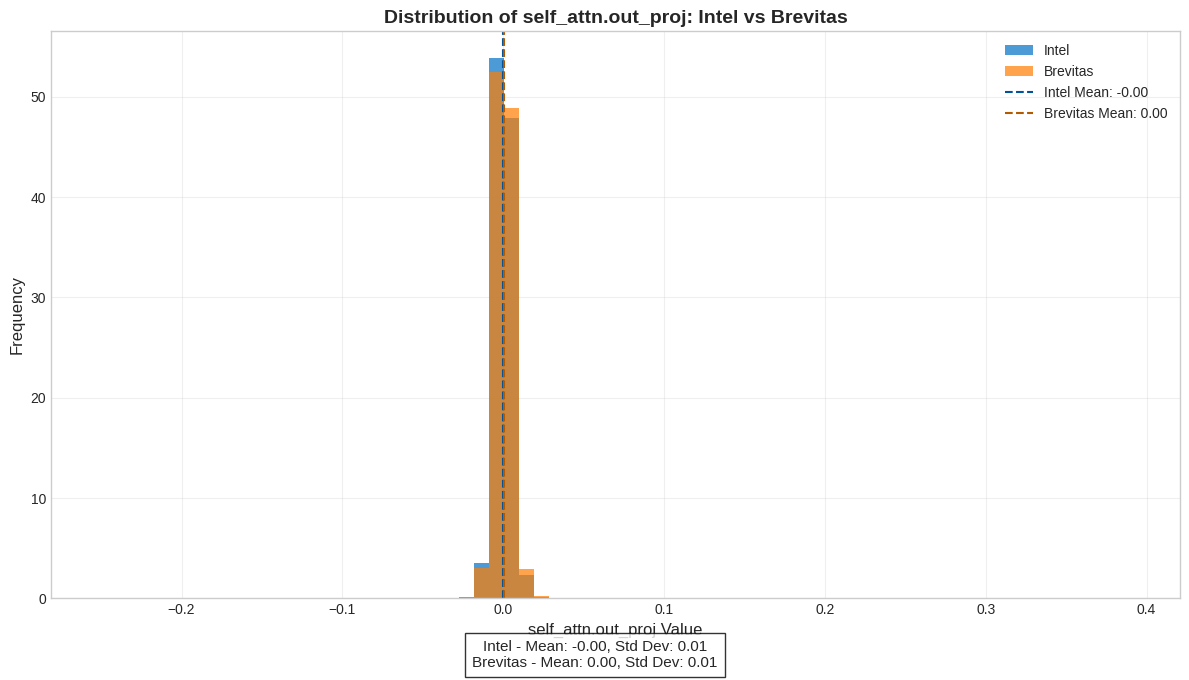

Created plot for self_attn.out_proj and saved to error_distribution_plots/04_self_attn.out_proj.png
tensor(22224.9902) tensor(22346.0371)


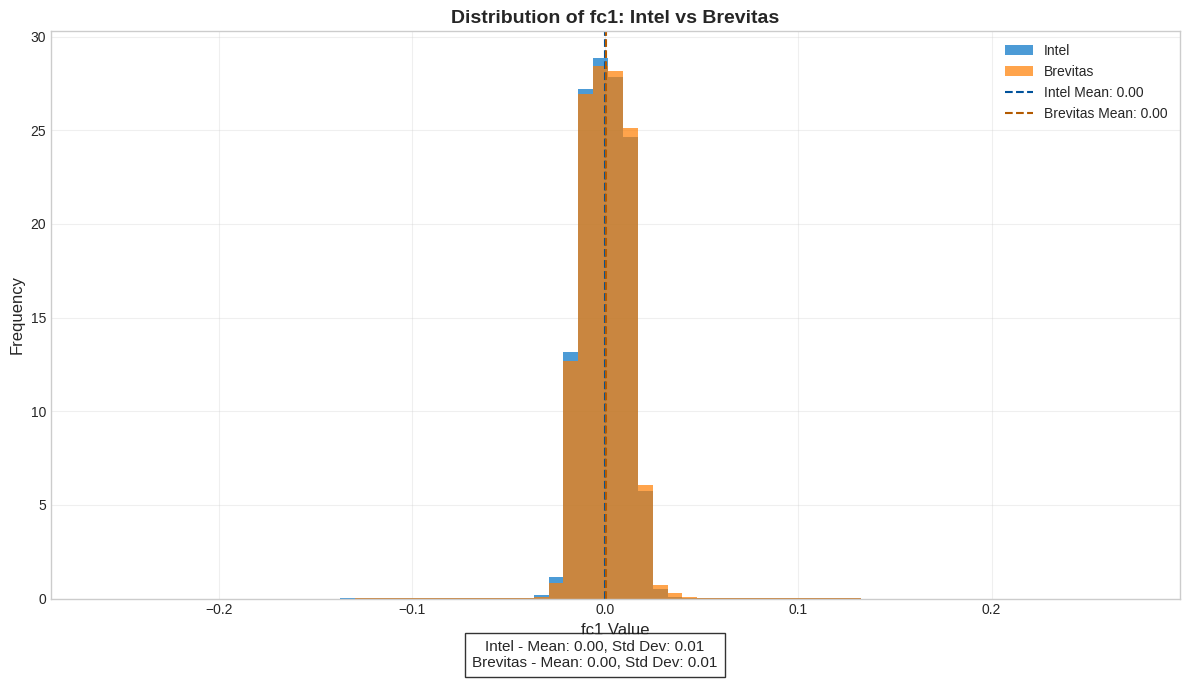

Created plot for fc1 and saved to error_distribution_plots/05_fc1.png
tensor(24460.5078) tensor(24867.0039)


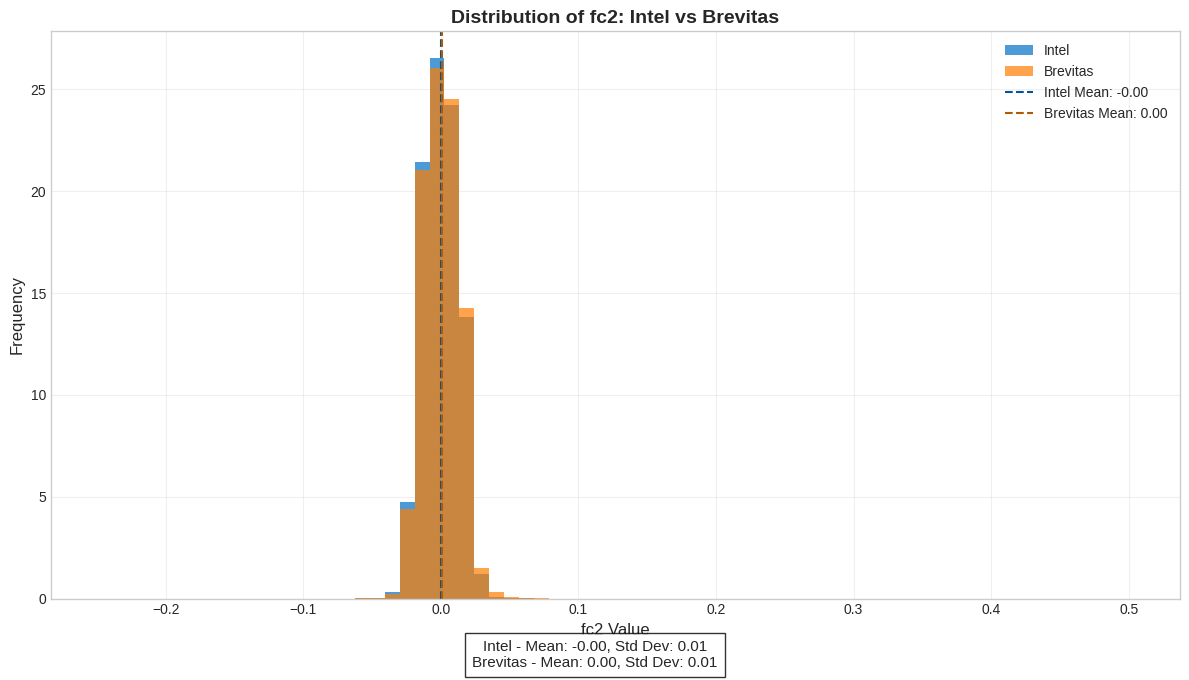

Created plot for fc2 and saved to error_distribution_plots/06_fc2.png
All plots have been saved to the 'error_distribution_plots' directory


In [42]:
import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as sns  
import os  
  
# Create a directory to save the figures if it doesn't exist  
save_dir = "error_distribution_plots"  
os.makedirs(save_dir, exist_ok=True)  
  
# Set the style for better aesthetics  
plt.style.use('seaborn-v0_8-whitegrid')  
sns.set_palette("pastel")  
  
# Define error measures to plot  
error_measures = [  
    "Mean Absolute Error",  
    "Root Mean Square Error",  
    "Relative Error",  
    "Percentage Error",  
    "Peak Signal-to-Noise Ratio"  
    # Add more measures as needed  
]  
bit_width = 2

# Loop through each error measure and create a separate figure  
for i, (name, weight) in enumerate(weights): 
    # Generate data for this measure  
    qdq_intel, _, _ = quant_tensor_sym(weight, bits=bit_width)
    intel_errors = (weight - qdq_intel).reshape(-1)

    qdq_brevitas, _, _ = quant_tensor_sym_brevitas(weight, bits=bit_width)
    brevitas_errors = (weight - qdq_brevitas).reshape(-1)
      
    # Create the figure and axis  
    fig, ax = plt.subplots(figsize=(12, 7))  
      
    # Determine reasonable bin range based on the data  
    min_val = min(intel_errors.min(), brevitas_errors.min())  
    max_val = max(intel_errors.max(), brevitas_errors.max())  
    bins = np.linspace(min_val, max_val, 70)  

    print(torch.sum(torch.abs(intel_errors)), torch.sum(torch.abs(brevitas_errors)))
      
    # Plot histograms  
    ax.hist(intel_errors, density=True, bins=bins, alpha=0.7, label='Intel', color='#0071c5')  # Intel blue  
    ax.hist(brevitas_errors, density=True, bins=bins, alpha=0.7, label='Brevitas', color='#ff7e00')  # Orange for Brevitas  
      
    # Add vertical lines for means  
    ax.axvline(intel_errors.mean(), color='#00529b', linestyle='dashed', linewidth=1.5,   
               label=f'Intel Mean: {intel_errors.mean():.2f}')  
    ax.axvline(brevitas_errors.mean(), color='#b35a00', linestyle='dashed', linewidth=1.5,  
               label=f'Brevitas Mean: {brevitas_errors.mean():.2f}')  
      
    # Customize the plot  
    ax.set_xlabel(f'{name} Value', fontsize=12)  
    ax.set_ylabel('Frequency', fontsize=12)  
    ax.set_title(f'Distribution of {name}: Intel vs Brevitas', fontsize=14, fontweight='bold')  
    ax.legend(fontsize=10)  
      
    # Add text with statistical information  
    stats_text = (  
        f"Intel - Mean: {intel_errors.mean():.2f}, Std Dev: {intel_errors.std():.2f}\n"  
        f"Brevitas - Mean: {brevitas_errors.mean():.2f}, Std Dev: {brevitas_errors.std():.2f}"  
    )  
    plt.figtext(0.5, 0.01, stats_text, ha='center', fontsize=11, bbox={'facecolor':'white', 'alpha':0.8, 'pad':5})  
      
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])  
    plt.grid(alpha=0.3)  
      
    # Save the figure  
    filename = f"{i+1:02d}_{name.replace(' ', '_').lower()}.png"  
    filepath = os.path.join(save_dir, filename)  
    plt.show()
      
    print(f"Created plot for {name} and saved to {filepath}")  
  
print(f"All plots have been saved to the '{save_dir}' directory")  
